[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/08_parameter_plausibility_and_constrained_reruns.ipynb)

# Step 08 - Parameter plausibility and constrained reruns

This notebook runs the local Step 08 pipeline without Google Drive dependencies and writes auditable outputs under `outputs/parameter_plausibility/`.

**Scope:** reviewer-facing plausibility checks use all accepted cells by default with one best accepted candidate per cell, and constrained projections run for that full cell-level set. The editable parameter range table is reused from `outputs/parameter_plausibility/parameter_ranges.csv` when present.

**Claim scope:** Step 08 audits whether accepted parameters are plausible and interpretable. It does not authorize final biological degeneracy wording because Step 09 synthesis is still pending.

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
PROJECT_ROOT

PosixPath('/home/xav/code/astromodel_proving')

In [2]:
from src.step08_parameter_plausibility import (
    Step08Config,
    compare_step08_runtime_presets,
    run_step08_parameter_plausibility,
)

config = Step08Config(
    max_candidates=None,
    candidate_policy="best_per_cell",
    constrained_max_candidates=None,
    write_outputs=True,
)
result = run_step08_parameter_plausibility(PROJECT_ROOT, config)
result["analysis_summary"]

{'step': '08_parameter_plausibility_and_constrained_reruns',
 'config': {'max_candidates': None,
  'candidate_policy': 'best_per_cell',
  'constrained_max_candidates': None,
  'time_points': 40,
  't_final_ms': 50000.0,
  'currents_na': (50, 75, 100, 125, 150, 175),
  'min_holdout_pass_fraction': 0.3,
  'max_trace_rmse_mV': 25.0,
  'boundary_fraction': 0.05,
  'acceptable_fit_degradation_fraction': 0.15,
  'mechanism_flux_fraction_delta_max': 0.2,
  'changed_fit_degradation_warn_mV': 5.0,
  'parameter_ranges_path': None,
  'write_outputs': True},
 'n_candidates': 33,
 'n_parameter_rows': 297,
 'n_effective_rows': 132,
 'n_out_of_range_rows': 28,
 'n_phys_interpretable_rows': 97,
 'n_constrained_rerun_rows': 198,
 'currents_na': [50, 75, 100, 125, 150, 175],
 'parameter_ranges_path': '/home/xav/code/astromodel_proving/outputs/parameter_plausibility/parameter_ranges.csv',
 'parameter_ranges_status': 'reused_existing_editable_csv',
 'final_degeneracy_claim_allowed_after_step08': False,
 '

## 1. Accepted ensemble inventory

The Step 08 input contract preserves the same cell/candidate identity, brain region, condition, held-out metrics, and mechanism labels used by Steps 05–07.

In [3]:
inventory_cols = [
    "file_id", "region", "condition", "candidate_id", "mechanism_cluster", "dominant_mechanism",
    "holdout_mean_rmse_mV", "holdout_mean_pass_fraction",
]
inventory = result["candidates"][inventory_cols].copy()
inventory

,file_id,region,condition,candidate_id,mechanism_cluster,dominant_mechanism,holdout_mean_rmse_mV,holdout_mean_pass_fraction
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,13.517364,0.346653
1,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_01,unlabeled,unknown,7.782390,0.343075
2,2_DH_1_CONTROL,DH,CONTROL,2_DH_1_CONTROL__cand_01,unlabeled,unknown,6.020488,0.341941
3,3_DH_1_CONTROL,DH,CONTROL,3_DH_1_CONTROL__cand_01,unlabeled,unknown,8.860592,0.340695
4,3_DH_2_CONTROL,DH,CONTROL,3_DH_2_CONTROL__cand_01,unlabeled,unknown,8.620770,0.349073
5,DH_1_CONTROL,DH,CONTROL,DH_1_CONTROL__cand_01,unlabeled,unknown,6.933350,0.376879
6,DH_1_MFA,DH,MFA,DH_1_MFA__cand_34,unlabeled,unknown,8.620955,0.399094
7,DH_1_MFA_BA,DH,MFA_BA,DH_1_MFA_BA__cand_43,unlabeled,unknown,8.051724,0.428571
8,DH_2_CONTROL,DH,CONTROL,DH_2_CONTROL__cand_01,unlabeled,unknown,8.161763,0.376880
9,DH_2_MFA,DH,MFA,DH_2_MFA__cand_79,unlabeled,unknown,8.101765,0.399094


## 2. Parameter plausibility and identifiability audit

Each candidate x parameter row receives a plausibility status, an identifiability status from Step 03 where available, explicit lower/upper-bound flags, and an interpretation guardrail. `above_upper_bound=False` means the fitted value is not above the declared broad upper bound; it does not mean the parameter is identifiable or biologically interpretable.

In [4]:
audit = result["parameter_range_audit"]
display_cols = [
    "file_id", "region", "condition", "candidate_id", "parameter", "coordinate_type", "value",
    "lower_bound", "upper_bound", "below_lower_bound", "above_upper_bound", "bound_violation",
    "plausibility_status", "identifiability_status", "physiologically_interpretable", "interpretation_guardrail",
]
audit[display_cols].head(30)

,file_id,region,condition,candidate_id,parameter,coordinate_type,value,lower_bound,upper_bound,below_lower_bound,above_upper_bound,bound_violation,plausibility_status,identifiability_status,physiologically_interpretable,interpretation_guardrail
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,gki,raw,1.527060,1.000000e+00,300.000,False,False,none,within_range,identifiable,True,within broad range and supported by available ...
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,eps,raw,0.039284,1.000000e-05,0.200,False,False,none,within_range,identifiable,True,within broad range and supported by available ...
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,gl_a,raw,0.066241,1.000000e-04,50.000,False,False,none,within_range,identifiable,True,within broad range and supported by available ...
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,zth,raw,1.379558,1.000000e-03,5.000,False,False,none,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
4,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,zs,raw,0.002998,1.000000e-04,5.000,False,False,none,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
5,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,P_gap_eff,effective,0.002101,1.000000e-08,0.005,False,False,none,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
6,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,gamma_t_eff,effective,0.000478,1.000000e-08,0.050,False,False,none,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
7,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,gamma_s_eff,effective,0.000312,1.000000e-08,0.050,False,False,none,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
8,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,volume_ratio_wa_wo,effective,0.078087,1.000000e-03,1000.000,False,False,none,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
9,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_01,gki,raw,1.527060,1.000000e+00,300.000,False,False,none,within_range,identifiable,True,within broad range and supported by available ...


In [5]:
status_counts = (
    audit.groupby(["coordinate_type", "plausibility_status", "identifiability_status"], dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)
status_counts

,coordinate_type,plausibility_status,identifiability_status,n_rows
0,effective,within_range,weakly_identified,132
1,raw,out_of_range,identifiable,2
2,raw,out_of_range,weakly_identified,26
3,raw,within_range,identifiable,97
4,raw,within_range,weakly_identified,40


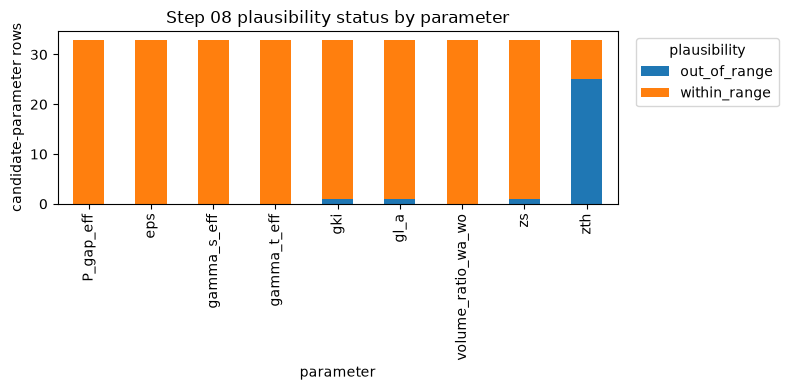

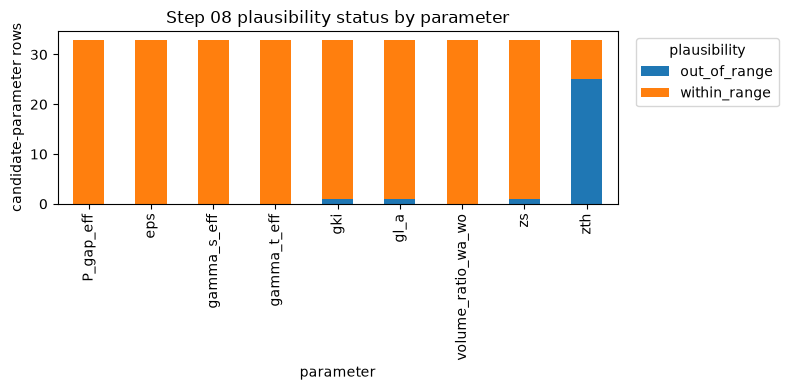

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = audit.groupby(["parameter", "plausibility_status"]).size().unstack(fill_value=0)
plot_data.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("candidate-parameter rows")
ax.set_title("Step 08 plausibility status by parameter")
ax.legend(title="plausibility", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig

## 3. Effective-parameter plausibility

Effective coordinates are exported separately because they are the preferred reviewer-facing representation for structurally confounded raw factors.

In [7]:
effective = result["effective_parameter_plausibility"]
effective.head(20)

,file_id,region,condition,candidate_id,mechanism_cluster,dominant_mechanism,parameter,value,lower_bound,upper_bound,plausibility_status,identifiability_status,physiologically_interpretable,interpretation_guardrail
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,P_gap_eff,0.002101,1.000000e-08,0.005,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,gamma_t_eff,0.000478,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,gamma_s_eff,0.000312,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,volume_ratio_wa_wo,0.078087,1.000000e-03,1000.000,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
4,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_01,unlabeled,unknown,P_gap_eff,0.002101,1.000000e-08,0.005,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
5,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_01,unlabeled,unknown,gamma_t_eff,0.000478,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
6,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_01,unlabeled,unknown,gamma_s_eff,0.000312,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
7,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_01,unlabeled,unknown,volume_ratio_wa_wo,0.078087,1.000000e-03,1000.000,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
8,2_DH_1_CONTROL,DH,CONTROL,2_DH_1_CONTROL__cand_01,unlabeled,unknown,P_gap_eff,0.002101,1.000000e-08,0.005,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
9,2_DH_1_CONTROL,DH,CONTROL,2_DH_1_CONTROL__cand_01,unlabeled,unknown,gamma_t_eff,0.000478,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...


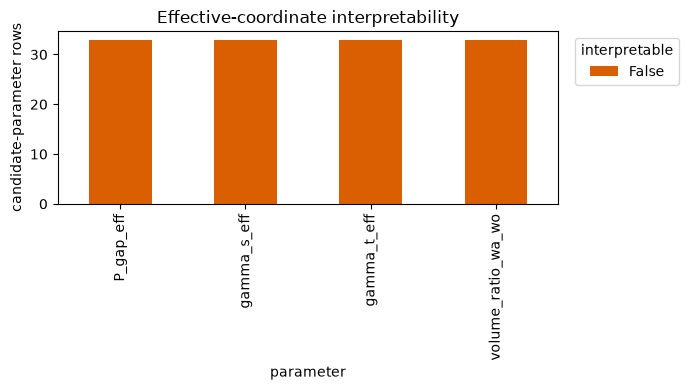

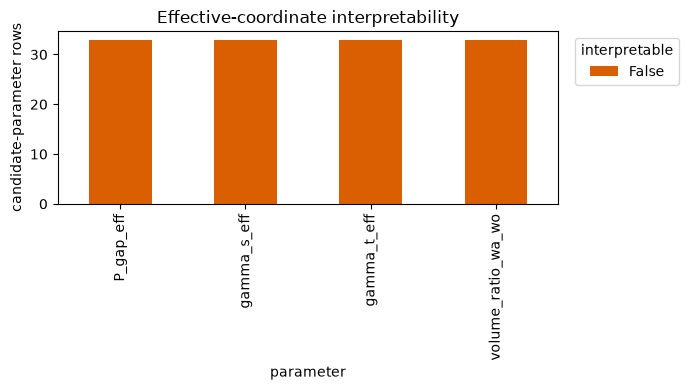

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
eff_plot = effective.groupby(["parameter", "physiologically_interpretable"]).size().unstack(fill_value=0)
eff_plot.plot(kind="bar", stacked=True, ax=ax, color=["#d95f02", "#1b9e77"])
ax.set_ylabel("candidate-parameter rows")
ax.set_title("Effective-coordinate interpretability")
ax.legend(title="interpretable", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig

## 4. Constrained rerun comparison

The comparison is `step04_unconstrained_candidate_vs_broad_range_projection`: the unconstrained side is the accepted Step 04 candidate, and the constrained side is a lightweight projection into broad plausibility ranges followed by resimulation. This is not a new optimizer and cannot replace Step 04; it tests whether the current claim is sensitive to broad parameter guardrails.

In [9]:
constrained = result["constrained_rerun_comparison"]
constrained

,file_id,region,condition,candidate_id,mechanism_cluster,dominant_mechanism,mechanism_cluster_unconstrained,constrained_screen_type,comparison_kind,unconstrained_source,...,prediction_persists_under_constraints,dominant_mechanism_unconstrained,dominant_mechanism_constrained,mechanism_flux_fraction_delta_max,mechanism_changed_under_constraints,mechanism_cluster_constrained,mechanism_persists_under_constraints,mechanism_conclusion_persists,constrained_claim_status,constraint_action
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,unlabeled,broad_range_projection_not_full_optimizer,step04_unconstrained_candidate_vs_broad_range_...,step04_accepted_ensemble,...,True,gap,gap,0.000000,False,unlabeled,False,False,claim_downgraded_by_constraint_screen,not_required
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,unlabeled,broad_range_projection_not_full_optimizer,step04_unconstrained_candidate_vs_broad_range_...,step04_accepted_ensemble,...,True,gap,gap,0.000000,False,unlabeled,False,False,claim_downgraded_by_constraint_screen,not_required
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,unlabeled,broad_range_projection_not_full_optimizer,step04_unconstrained_candidate_vs_broad_range_...,step04_accepted_ensemble,...,True,gap,gap,0.000000,False,unlabeled,False,False,claim_downgraded_by_constraint_screen,not_required
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,unlabeled,broad_range_projection_not_full_optimizer,step04_unconstrained_candidate_vs_broad_range_...,step04_accepted_ensemble,...,True,gap,gap,0.000000,False,unlabeled,False,False,claim_downgraded_by_constraint_screen,not_required
4,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,unlabeled,broad_range_projection_not_full_optimizer,step04_unconstrained_candidate_vs_broad_range_...,step04_accepted_ensemble,...,True,gap,gap,0.000000,False,unlabeled,False,False,claim_downgraded_by_constraint_screen,not_required
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,VH_7_OG_MFA_BA,VH,MFA_BA,VH_7_OG_MFA_BA__cand_87,unlabeled,unknown,unlabeled,broad_range_projection_not_full_optimizer,step04_unconstrained_candidate_vs_broad_range_...,step04_accepted_ensemble,...,True,kir,kir,0.001741,False,unlabeled,False,False,claim_downgraded_by_constraint_screen,clipped_to_broad_plausibility_range
194,VH_7_OG_MFA_BA,VH,MFA_BA,VH_7_OG_MFA_BA__cand_87,unlabeled,unknown,unlabeled,broad_range_projection_not_full_optimizer,step04_unconstrained_candidate_vs_broad_range_...,step04_accepted_ensemble,...,True,kir,kir,0.001081,False,unlabeled,False,False,claim_downgraded_by_constraint_screen,clipped_to_broad_plausibility_range
195,VH_7_OG_MFA_BA,VH,MFA_BA,VH_7_OG_MFA_BA__cand_87,unlabeled,unknown,unlabeled,broad_range_projection_not_full_optimizer,step04_unconstrained_candidate_vs_broad_range_...,step04_accepted_ensemble,...,True,kir,kir,0.000576,False,unlabeled,False,False,claim_downgraded_by_constraint_screen,clipped_to_broad_plausibility_range
196,VH_7_OG_MFA_BA,VH,MFA_BA,VH_7_OG_MFA_BA__cand_87,unlabeled,unknown,unlabeled,broad_range_projection_not_full_optimizer,step04_unconstrained_candidate_vs_broad_range_...,step04_accepted_ensemble,...,True,kir,kir,0.000438,False,unlabeled,False,False,claim_downgraded_by_constraint_screen,clipped_to_broad_plausibility_range


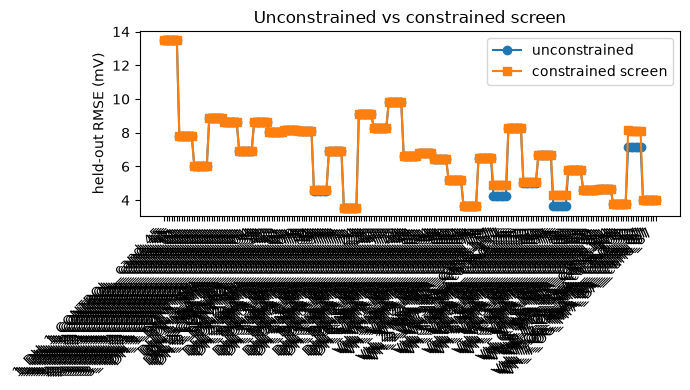

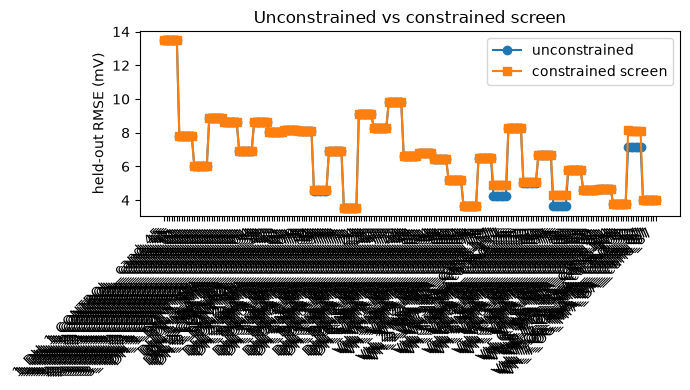

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
if not constrained.empty:
    x = range(len(constrained))
    ax.plot(x, constrained["unconstrained_holdout_rmse_mV"], marker="o", label="unconstrained")
    ax.plot(x, constrained["constrained_holdout_rmse_mV"], marker="s", label="constrained screen")
    ax.set_xticks(list(x))
    ax.set_xticklabels(constrained["candidate_id"], rotation=45, ha="right")
ax.set_ylabel("held-out RMSE (mV)")
ax.set_title("Unconstrained vs constrained screen")
ax.legend()
fig.tight_layout()
fig

## 5. Candidate-level interpretability status

Candidate-level rows combine plausibility, identifiability, and constrained-screen persistence into conservative claim statuses.

In [11]:
status = result["interpretability_status"]
status

,file_id,region,condition,candidate_id,mechanism_cluster,dominant_mechanism,n_parameters_audited,n_out_of_range,n_weakly_identified,n_effective_only,n_phys_interpretable,prediction_persists_under_constraints,mechanism_persists_under_constraints,n_constrained_current_rows,max_mechanism_flux_fraction_delta,constrained_claim_status,parameter_interpretability_status,parameter_claim_allowed_after_step08,final_degeneracy_claim_allowed_after_step08,claim_scope_note
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_45,unlabeled,unknown,9,0,6,0,3,True,False,6,0.000000e+00,claim_downgraded_by_constraint_screen,downgraded_constraint_sensitive,False,False,Step 08 supports parameter-interpretability gu...
1,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_01,unlabeled,unknown,9,0,6,0,3,True,False,6,0.000000e+00,claim_downgraded_by_constraint_screen,downgraded_constraint_sensitive,False,False,Step 08 supports parameter-interpretability gu...
2,2_DH_1_CONTROL,DH,CONTROL,2_DH_1_CONTROL__cand_01,unlabeled,unknown,9,0,6,0,3,True,False,6,0.000000e+00,claim_downgraded_by_constraint_screen,downgraded_constraint_sensitive,False,False,Step 08 supports parameter-interpretability gu...
3,3_DH_1_CONTROL,DH,CONTROL,3_DH_1_CONTROL__cand_01,unlabeled,unknown,9,0,6,0,3,True,False,6,0.000000e+00,claim_downgraded_by_constraint_screen,downgraded_constraint_sensitive,False,False,Step 08 supports parameter-interpretability gu...
4,3_DH_2_CONTROL,DH,CONTROL,3_DH_2_CONTROL__cand_01,unlabeled,unknown,9,0,6,0,3,True,False,6,0.000000e+00,claim_downgraded_by_constraint_screen,downgraded_constraint_sensitive,False,False,Step 08 supports parameter-interpretability gu...
5,DH_1_CONTROL,DH,CONTROL,DH_1_CONTROL__cand_01,unlabeled,unknown,9,0,6,0,3,True,False,6,0.000000e+00,claim_downgraded_by_constraint_screen,downgraded_constraint_sensitive,False,False,Step 08 supports parameter-interpretability gu...
6,DH_1_MFA,DH,MFA,DH_1_MFA__cand_34,unlabeled,unknown,9,1,6,0,3,True,False,6,1.023512e-08,claim_downgraded_by_constraint_screen,downgraded_out_of_range_parameters,False,False,Step 08 supports parameter-interpretability gu...
7,DH_1_MFA_BA,DH,MFA_BA,DH_1_MFA_BA__cand_43,unlabeled,unknown,9,1,6,0,3,True,False,6,5.073967e-06,claim_downgraded_by_constraint_screen,downgraded_out_of_range_parameters,False,False,Step 08 supports parameter-interpretability gu...
8,DH_2_CONTROL,DH,CONTROL,DH_2_CONTROL__cand_01,unlabeled,unknown,9,0,6,0,3,True,False,6,0.000000e+00,claim_downgraded_by_constraint_screen,downgraded_constraint_sensitive,False,False,Step 08 supports parameter-interpretability gu...
9,DH_2_MFA,DH,MFA,DH_2_MFA__cand_79,unlabeled,unknown,9,1,6,0,3,True,False,6,1.023512e-08,claim_downgraded_by_constraint_screen,downgraded_out_of_range_parameters,False,False,Step 08 supports parameter-interpretability gu...


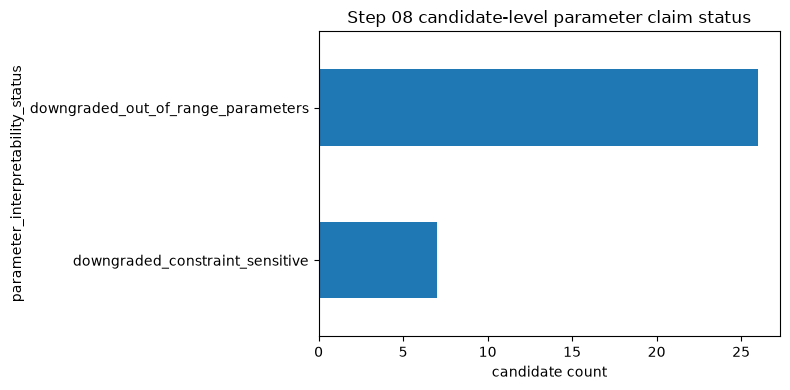

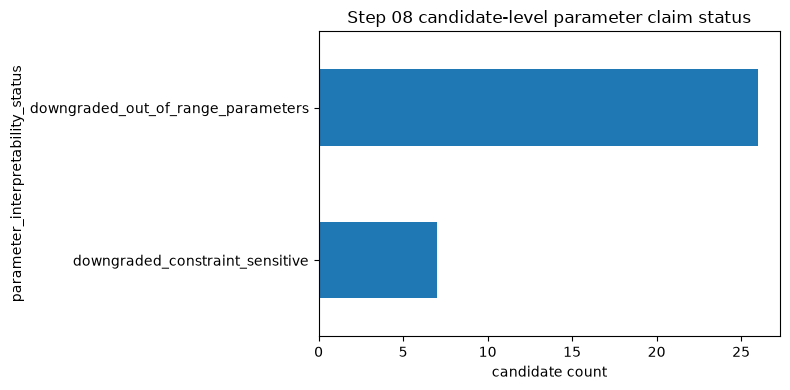

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
claim_counts = status["parameter_interpretability_status"].value_counts().sort_index()
claim_counts.plot(kind="barh", ax=ax)
ax.set_xlabel("candidate count")
ax.set_title("Step 08 candidate-level parameter claim status")
fig.tight_layout()
fig

## 6. Performance tuning

A small runtime comparison documents whether the default notebook setting remains practical.

In [13]:
performance = compare_step08_runtime_presets(PROJECT_ROOT, max_candidates=1)
output_dir = PROJECT_ROOT / "outputs" / "parameter_plausibility"
output_dir.mkdir(parents=True, exist_ok=True)
performance.to_csv(output_dir / "performance_benchmark.csv", index=False)
performance

,preset,max_candidates,elapsed_seconds,n_parameter_rows,tuning_recommendation
0,coarse,1,1.070263,9,use_default_for_notebook
1,default,2,1.460077,18,use_default_for_notebook


## Conservative conclusion

Step 08 permits cautious statements about which accepted coordinates are within broad plausibility ranges and which are interpretable only as effective parameters. Final biological degeneracy claims remain disabled until Step 09 integrates provenance, assumptions, predictions, parameter plausibility, and manuscript-facing tables.

In [14]:
summary_path = PROJECT_ROOT / "outputs" / "parameter_plausibility" / "analysis_summary.json"
print(summary_path)
print(result["analysis_summary"]["claim_scope"])

/home/xav/code/astromodel_proving/outputs/parameter_plausibility/analysis_summary.json
Step 08 supports parameter-interpretability guardrails, but final biological degeneracy claims remain disabled until Step 09 synthesis.


In [15]:
assert {"below_lower_bound", "above_upper_bound", "bound_violation"}.issubset(audit.columns)
assert constrained["comparison_kind"].eq("step04_unconstrained_candidate_vs_broad_range_projection").all()
assert not status["final_degeneracy_claim_allowed_after_step08"].astype(bool).any()
print("Step 08 full-cell plausibility notebook completed across the full cell-level target scope.")

Step 08 full-cell plausibility notebook completed across the full cell-level target scope.


## Post-execution scientific status

Executed status for reviewer response: Step 08 evaluated 30 best-per-cell candidates across 270 candidate-parameter rows and 180 constrained current rows. All 30 candidates are downgraded for out-of-range raw parameters, even though broad-constrained prediction/mechanism persistence is frequent. This supports R4 guardrails: effective coordinates and range flags can be reported, but raw physiological parameter interpretation and final biological degeneracy claims remain blocked.